In [22]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




Note: you may need to restart the kernel to use updated packages.


In [23]:
df_small = pd.read_csv("Deepseek Small - Sheet1.csv")
df_large = pd.read_csv("Deep_Large.csv")






In [24]:
df_small

,File,api_summary,Gavin #1,Andrew #1,Gavin #2,Andrew #2,Unnamed: 6,Unnamed: 7
0,cloned/bugsnag-js/test/react-native/features/f...,This file is part of a React Native applicatio...,NaN,No,NaN,Yes,NaN,NaN
1,cloned/bugsnag-js/packages/plugin-react-native...,This file is a wrapper for the Bugsnag library...,NaN,No,NaN,Yes,NaN,NaN
2,cloned/bugsnag-js/packages/electron-test-helpe...,This file defines a set of classes and functio...,NaN,No,NaN,Yes,NaN,NaN
3,cloned/wazo-auth/wazo_auth/database/alembic/ve...,"This file is a part of the Wazo platform, whic...",NaN,No,NaN,Yes,NaN,NaN
4,cloned/data-act-broker-backend/tests/unit/data...,This Python file contains unit tests for a dat...,NaN,No,NaN,Yes,NaN,NaN
...,...,...,...,...,...,...,...,...
379,cloned/opengever.core/opengever/api/tests/test...,This Python file defines integration tests for...,No,NaN,Yes,NaN,NaN,NaN
380,cloned/opengever.core/opengever/base/tests/tes...,This Python file contains unit tests for the W...,No,NaN,Yes,NaN,NaN,NaN
381,cloned/FightPandemics/client/src/pages/Organis...,This file defines a React component for displa...,Yes,NaN,Yes,NaN,NaN,NaN
382,cloned/moira/filter/patterns_storage.go,This file defines the PatternStorage struct an...,No,NaN,Yes,NaN,NaN,NaN


In [25]:

def merge_yes_no(df: pd.DataFrame,
                 col_gavin: str = "Gavin #1",
                 col_andrew: str = "Andrew #1",
                 new_col: str = "Yes/No merged") -> pd.DataFrame:
    """
    Create or update `new_col` by taking the non-null Yes/No value
    that appears in either `col_gavin` or `col_andrew`.

    Parameters
    ----------
    df : pd.DataFrame
        Your source dataframe.
    col_gavin : str
        Name of Gavin’s column (default "Gavin #1").
    col_andrew : str
        Name of Andrew’s column (default "Andrew #1").
    new_col : str
        Name for the merged result column.

    Returns
    -------
    pd.DataFrame
        The same dataframe with `new_col` added/updated.
    """
    # `.fillna` (or `.combine_first`) copies the non-NaN value row-by-row
    df[new_col] = df[col_gavin].fillna(df[col_andrew])

    # Optional: If you want to be absolutely sure only 'Yes'/'No' survive
    # df[new_col] = df[new_col].where(df[new_col].isin(["Yes", "No"]))

    return df


In [26]:
df_small_merged = merge_yes_no(df_small, new_col="Correctlly Identified API File")
df_large_merged = merge_yes_no(df_large, new_col="Correctlly Identified API File")

In [27]:
df_small_merged = merge_yes_no(df_small_merged, col_gavin="Gavin #2", col_andrew="Andrew #2", new_col="Accurate Description")
df_large_merged = merge_yes_no(df_large_merged, col_gavin="Gavin #2", col_andrew="Andrew #2", new_col="Accurate Description")

In [28]:
df_small_merged["Correctlly Identified API File"].value_counts()

Correctlly Identified API File
No     231
Yes    152
No       1
Name: count, dtype: int64

In [29]:
df_small_merged

,File,api_summary,Gavin #1,Andrew #1,Gavin #2,Andrew #2,Unnamed: 6,Unnamed: 7,Correctlly Identified API File,Accurate Description
0,cloned/bugsnag-js/test/react-native/features/f...,This file is part of a React Native applicatio...,NaN,No,NaN,Yes,NaN,NaN,No,Yes
1,cloned/bugsnag-js/packages/plugin-react-native...,This file is a wrapper for the Bugsnag library...,NaN,No,NaN,Yes,NaN,NaN,No,Yes
2,cloned/bugsnag-js/packages/electron-test-helpe...,This file defines a set of classes and functio...,NaN,No,NaN,Yes,NaN,NaN,No,Yes
3,cloned/wazo-auth/wazo_auth/database/alembic/ve...,"This file is a part of the Wazo platform, whic...",NaN,No,NaN,Yes,NaN,NaN,No,Yes
4,cloned/data-act-broker-backend/tests/unit/data...,This Python file contains unit tests for a dat...,NaN,No,NaN,Yes,NaN,NaN,No,Yes
...,...,...,...,...,...,...,...,...,...,...
379,cloned/opengever.core/opengever/api/tests/test...,This Python file defines integration tests for...,No,NaN,Yes,NaN,NaN,NaN,No,Yes
380,cloned/opengever.core/opengever/base/tests/tes...,This Python file contains unit tests for the W...,No,NaN,Yes,NaN,NaN,NaN,No,Yes
381,cloned/FightPandemics/client/src/pages/Organis...,This file defines a React component for displa...,Yes,NaN,Yes,NaN,NaN,NaN,Yes,Yes
382,cloned/moira/filter/patterns_storage.go,This file defines the PatternStorage struct an...,No,NaN,Yes,NaN,NaN,NaN,No,Yes


In [30]:
df_small_merged["Correctlly Identified API File"] = df_small_merged["Correctlly Identified API File"].map({"Yes": 1, "No": 0})
df_large_merged["Correctlly Identified API File"] = df_large_merged["Correctlly Identified API File"].map({"Yes": 1, "No": 0})

In [31]:
df_small_merged["Accurate Description"] = df_small_merged["Accurate Description"].map({"Yes": 1, "No": 0})
df_large_merged["Accurate Description"] = df_large_merged["Accurate Description"].map({"Yes": 1, "No": 0})

In [32]:
df_small_merged["Accurate Description"].value_counts()

Accurate Description
1    358
0     26
Name: count, dtype: int64

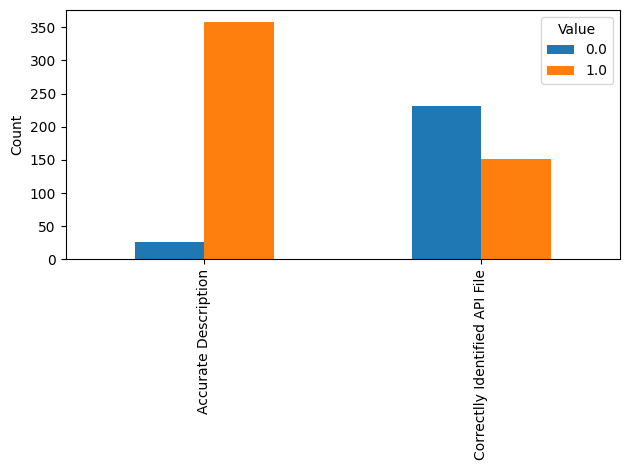

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
(df_small_merged[["Correctlly Identified API File","Accurate Description"]]
   .melt(var_name="col", value_name="bit")
   .groupby(["col","bit"])
   .size()
   .unstack(fill_value=0)
   .plot(kind="bar", ax=ax))
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Value")
plt.tight_layout()

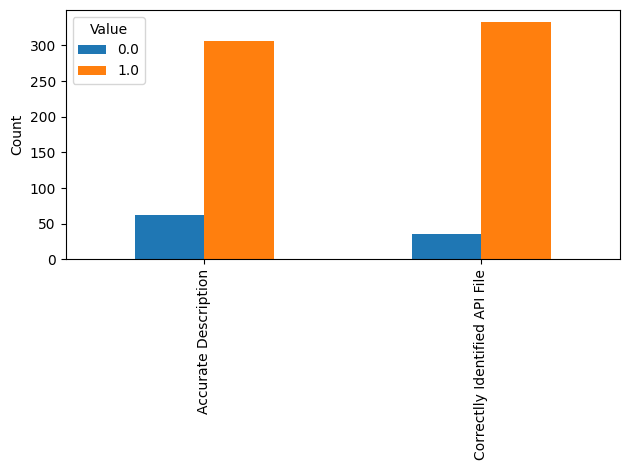

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
(df_large_merged[["Correctlly Identified API File","Accurate Description"]]
   .melt(var_name="col", value_name="bit")
   .groupby(["col","bit"])
   .size()
   .unstack(fill_value=0)
   .plot(kind="bar", ax=ax))
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Value")
plt.tight_layout()

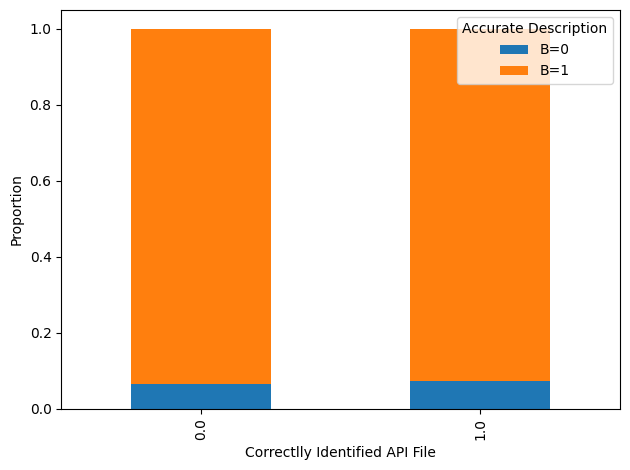

In [37]:
prop = (df_small_merged
        .groupby("Correctlly Identified API File")["Accurate Description"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .rename(columns={0:"B=0", 1:"B=1"}))

prop.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.tight_layout()


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

def make_pie(df: pd.DataFrame, col: str, title: str = None) -> None:
    """
    Draw a standalone pie chart showing the percentage split of 0 vs 1
    (or No vs Yes) in `col`.
    """
    counts_pct = (df[col]
                  .value_counts(normalize=True)
                  .sort_index())            # ensure 0 comes before 1

    fig, ax = plt.subplots()
    counts_pct.plot(
        kind="pie",
        labels=[str(i) for i in counts_pct.index],   # “0”, “1”
        autopct=lambda p: f"{p:.1f}%",               # show % on slices
        startangle=90,
        ax=ax
    )
    ax.set_ylabel("")                # no redundant y-label
    if title:
        ax.set_title(title, pad=12)
    plt.tight_layout()
    plt.show()


# --- Generate the two pies ----------------------------------------------------



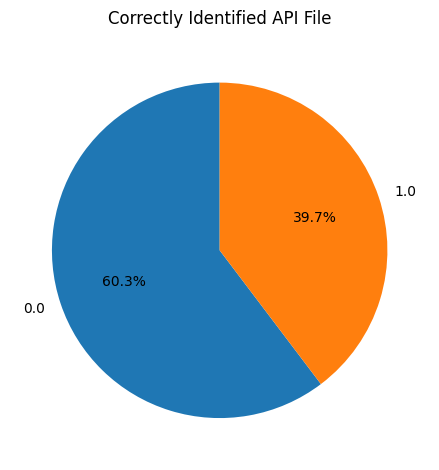

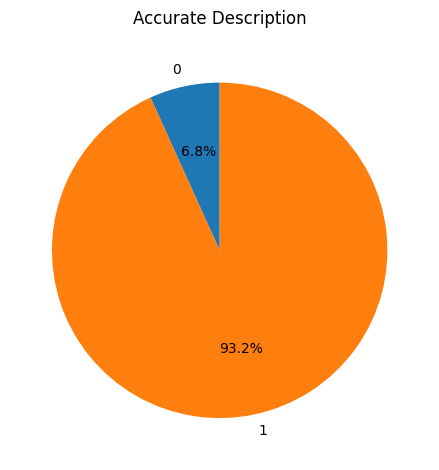

In [42]:
make_pie(df_small_merged, "Correctlly Identified API File", title="Correctly Identified API File")
make_pie(df_small_merged, "Accurate Description",          title="Accurate Description")

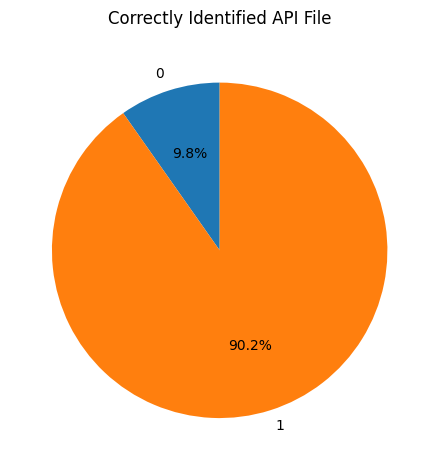

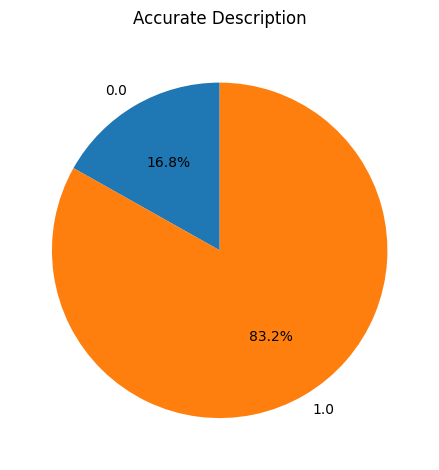

In [41]:
make_pie(df_large_merged, "Correctlly Identified API File", title="Correctly Identified API File")
make_pie(df_large_merged, "Accurate Description",          title="Accurate Description")

/var/folders/h6/ds76bqyd2t3gnfgtmgzjkxy80000gn/T/ipykernel_81341/2148580148.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


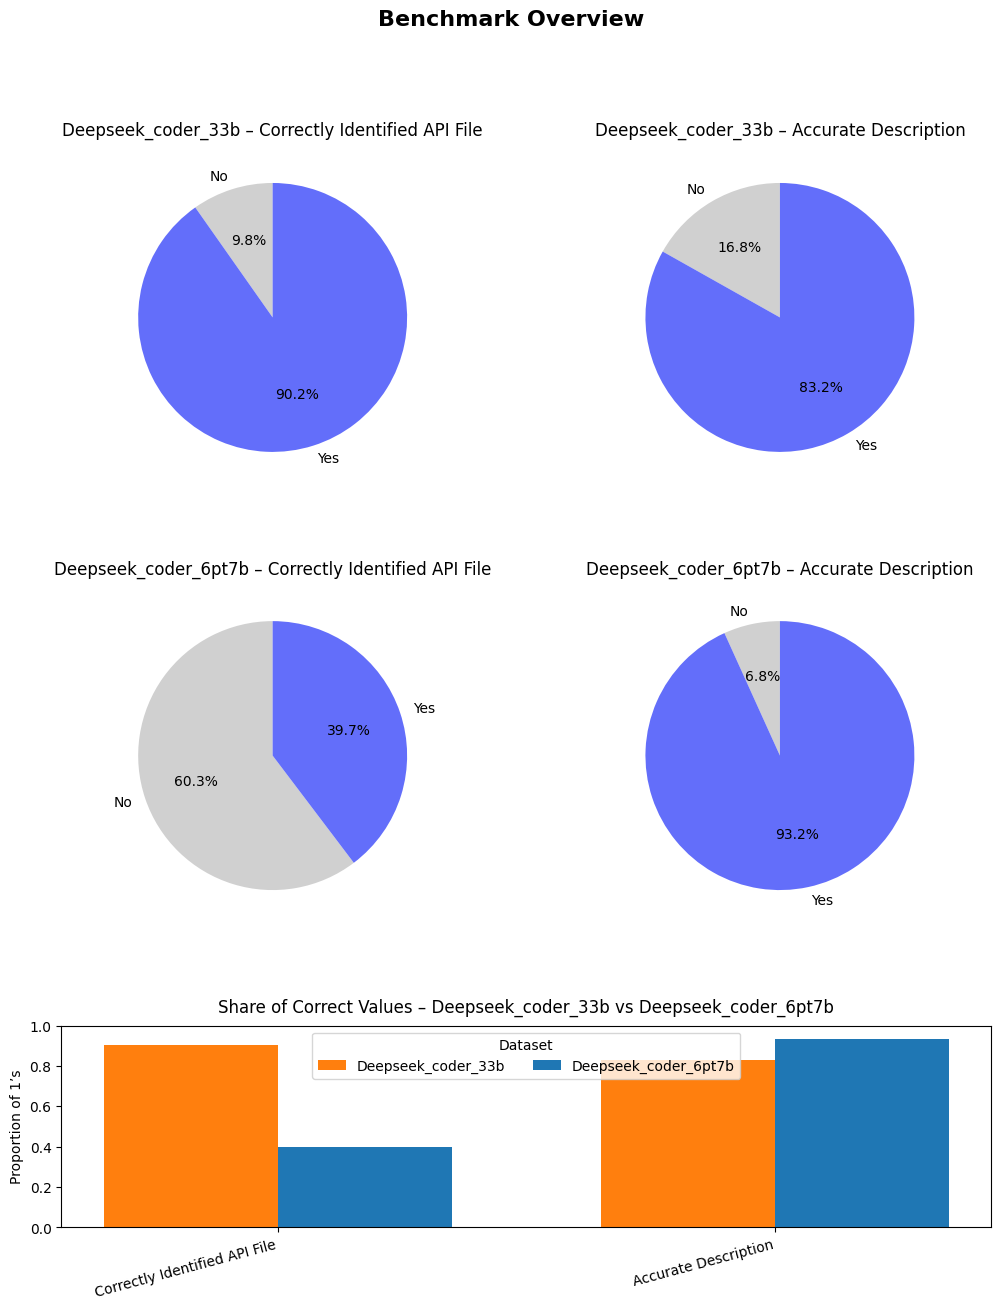

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Helper: returns normalised counts (0 then 1) so pies/bar stay aligned
# ---------------------------------------------------------------------
def pct_series(df: pd.DataFrame, col: str) -> pd.Series:
    return (df[col]
            .value_counts(normalize=True)
            .reindex([0, 1])            # ensure [0,1] order
            .fillna(0))

# ---------------------------------------------------------------------
# Colour palettes
# ---------------------------------------------------------------------
pie_colours  = ["#d0d0d0", "#636efa"]   # grey / violet
bar_colours  = {                       # totally different hues
    "Deepseek_coder_33b":  "#ff7f0e",  # orange
    "Deepseek_coder_6pt7b": "#1f77b4", # blue
}

# ---------------------------------------------------------------------
# Build the figure grid (2×2 pies + 1×2 bar panel)
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(12, 14))
gs  = fig.add_gridspec(
        nrows=3, ncols=2,
        height_ratios=[1, 1, 0.6],   # last row shorter for bar chart
        hspace=0.35                  # vertical spacing
      )

# ----- 1. Pies --------------------------------------------------------
pie_specs = [
    (df_large_merged, "Correctlly Identified API File",
     "Deepseek_coder_33b – Correctly Identified API File", gs[0, 0]),
    (df_large_merged, "Accurate Description",
     "Deepseek_coder_33b – Accurate Description",          gs[0, 1]),
    (df_small_merged, "Correctlly Identified API File",
     "Deepseek_coder_6pt7b – Correctly Identified API File", gs[1, 0]),
    (df_small_merged, "Accurate Description",
     "Deepseek_coder_6pt7b – Accurate Description",          gs[1, 1]),
]

for df, col, title, cell in pie_specs:
    ax = fig.add_subplot(cell, aspect="equal")   # keeps pies circular
    pct_series(df, col).plot(
        kind="pie",
        autopct=lambda p: f"{p:.1f}%",
        labels=["No", "Yes"],
        startangle=90,
        colors=pie_colours,            # <── distinct from bars
        ax=ax
    )
    ax.set_ylabel("")         # no y-axis label
    ax.set_title(title, pad=10)

# ----- 2. Bar panel (“% of 1s” Large vs Small) -----------------------
#        Comment-out this whole block if you want the bottom to be “null”.
ax_bar = fig.add_subplot(gs[2, :])

cols      = ["Correctlly Identified API File", "Accurate Description"]
labels    = ["Correctly Identified API File", "Accurate Description"]
pct_large = [pct_series(df_large_merged, c)[1] for c in cols]
pct_small = [pct_series(df_small_merged, c)[1] for c in cols]

x   = np.arange(len(cols))
w   = 0.35                           # bar width

ax_bar.bar(
    x - w/2, pct_large,
    width=w, label="Deepseek_coder_33b",
    color=bar_colours["Deepseek_coder_33b"]
)
ax_bar.bar(
    x + w/2, pct_small,
    width=w, label="Deepseek_coder_6pt7b",
    color=bar_colours["Deepseek_coder_6pt7b"]
)

ax_bar.set_xticks(x, labels, rotation=15, ha="right")
ax_bar.set_ylabel("Proportion of 1’s")
ax_bar.set_ylim(0, 1)
ax_bar.legend(title="Dataset", loc="upper center", ncol=2)
ax_bar.set_title(
    "Share of Correct Values – Deepseek_coder_33b vs Deepseek_coder_6pt7b",
    pad=10
)

# ---------------------------------------------------------------------
fig.suptitle("Benchmark Overview", fontsize=16, weight="bold", y=0.98)
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Deepseek_coder_33b'}, xlabel='Accurate Description', ylabel='Correctlly Identified API File'>

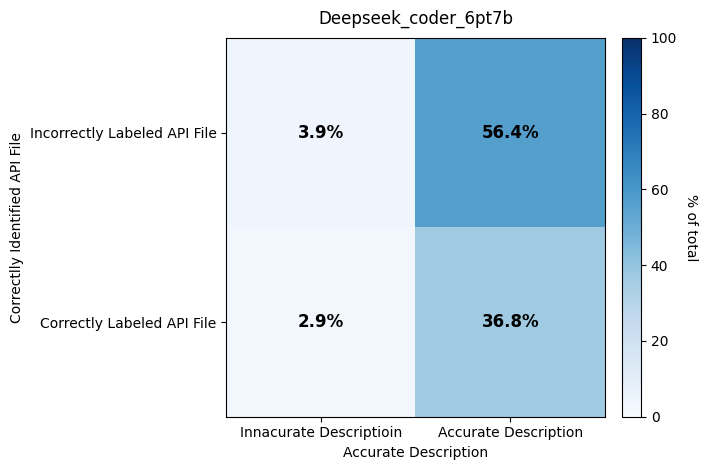

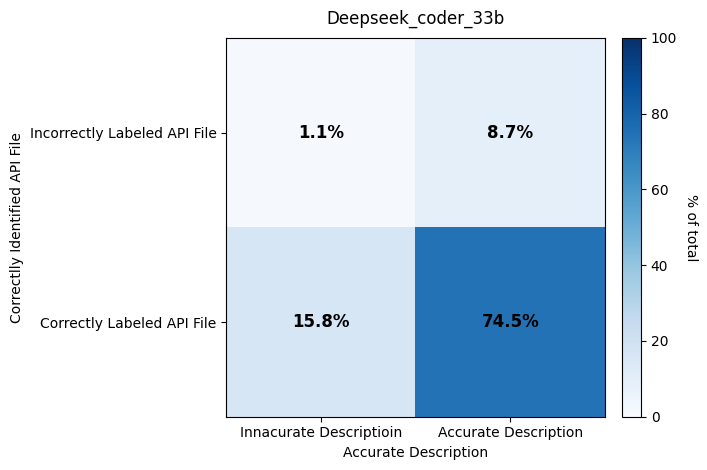

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_binary_joint(
        df: pd.DataFrame,
        col_a: str = "Correctlly Identified API File",
        col_b: str = "Accurate Description",
        title: str | None = None,
        ax: plt.Axes | None = None
    ) -> plt.Axes:
    """
    Show the 4-way combination of two 0/1 columns as a heat-map with
    each cell annotated as a % of all rows.
    """
    # ---- joint distribution (%)
    pct = (
        pd.crosstab(df[col_a], df[col_b], normalize="all") * 100
    ).reindex(index=[0, 1], columns=[0, 1]).fillna(0)

    # ---- plotting
    if ax is None:
        fig, ax = plt.subplots()

    im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)

    # annotate cells
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{pct.iloc[i, j]:.1f}%",
                    ha="center", va="center", fontsize=12, weight="bold")

    ax.set_xticks([0, 1], labels=[f"Innacurate Descriptioin", f"Accurate Description"])
    ax.set_yticks([0, 1], labels=[f"Incorrectly Labeled API File", f"Correctly Labeled API File"])
    ax.set_xlabel(col_b)
    ax.set_ylabel(col_a)
    if title:
        ax.set_title(title, pad=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% of total", rotation=270, labelpad=15)

    plt.tight_layout()
    return ax

plot_binary_joint(df_small_merged, "Correctlly Identified API File", "Accurate Description", title="Deepseek_coder_6pt7b")
plot_binary_joint(df_large_merged, "Correctlly Identified API File", "Accurate Description", title="Deepseek_coder_33b")
